## Calculate PSF (D50) as a function of image plane distance

Use the simple optical model to calculate the dependence of the PSF on the image plane distance, assuming a Cherenkov spectrum. The optics are described by the standard optical model data pack, from `resources/optical_model_data+pack.json`, which describes 

- the parameters of the ray tracing model, 
- the quantum efficency curve of the SiPM detetector, 
- the transmission curve of the lens,
- the atmospheric transmissivoty from the top of the atmosphere, and
- the refractive index of the lens as a function of photon energy.

The notebook loads the data pack and uses the thin-lens optical model to calculate the PSF for on-axis and off-axis rays (directed at pixel 8,8 in the camera) as a function of the image plane offset from its nominal position. This allows the focussing of the model to be adjusted should that be desired.

In [1]:
%matplotlib inline
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt

from pypanodecoder import optical_model

In [2]:
# Load the data pack which gives a dictionary of the items listed above
data_pack = optical_model.load_datapack()

In [3]:
# Calculate the PSF images for on-axis rays, keeping only the D50 (smallest diameter 
# containing 50% of the rays).
all_deltaF = np.linspace(-5,5,21)
all_d50 = np.zeros_like(all_deltaF)
for i,dF in enumerate(all_deltaF):
    _,_,_,_,_,_,_,dQ = optical_model.generate_psf_image(0.0,0.0,1000000,data_pack,calc_diameter=True, diameter_quantile=0.5, focal_offset=dF)
    all_d50[i] = dQ

In [4]:
# Calculate the PSF images for off-axis rays. The off-axs direction is defined by 
# the location on the nominal image plane (in pixels) into which the principal ray 
# arrives (centered at 0,0).
all_d50_offaxis = np.zeros_like(all_deltaF)
for i,dF in enumerate(all_deltaF):
    _,_,_,_,_,_,_,dQ = optical_model.generate_psf_image(8.0,8.0,1000000,data_pack,calc_diameter=True, diameter_quantile=0.5, focal_offset=dF)
    all_d50_offaxis[i] = dQ

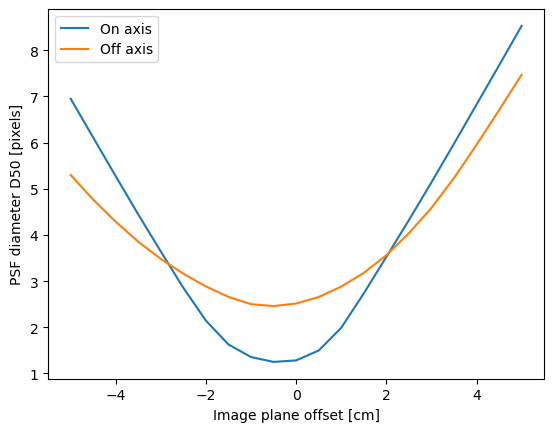

In [5]:
plt.plot(all_deltaF, all_d50,label='On axis')
plt.plot(all_deltaF, all_d50_offaxis,label='Off axis')
plt.xlabel('Image plane offset [cm]')
plt.ylabel('PSF diameter D50 [pixels]')
plt.legend(loc=2)